In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("cleaned_weather_traffic_dataset.csv")

In [3]:
print(df.shape)
print(df.info())
print(df.head())

(166105, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166105 entries, 0 to 166104
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   key                   166105 non-null  object 
 1   fare_amount           166105 non-null  float64
 2   pickup_datetime       166105 non-null  object 
 3   pickup_longitude      166105 non-null  float64
 4   pickup_latitude       166105 non-null  float64
 5   dropoff_longitude     166105 non-null  float64
 6   dropoff_latitude      166105 non-null  float64
 7   passenger_count       166105 non-null  int64  
 8   pickup_hour           166105 non-null  object 
 9   temperature           166105 non-null  float64
 10  precipitation         166105 non-null  float64
 11  wind_speed            166105 non-null  float64
 12  distance_km           166105 non-null  float64
 13  hour                  166105 non-null  int64  
 14  is_peak               166105 non-null  

In [4]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,temperature,precipitation,wind_speed,distance_km,hour,duration_min,traffic_duration_min,traffic_delay,avg_speed
count,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000,166105.000000
mean,8.408498,-73.919993,40.694590,-73.918915,40.694649,1.681786,11.847411,0.124780,11.554549,2.208558,13.606634,4.417113,5.902679,1.485566,22.809932
std,3.570321,2.585775,2.527463,2.585783,2.527473,1.400566,10.500723,0.511973,5.774587,1.326063,6.404363,2.652080,3.633811,1.288886,2.981875
min,0.010000,-75.387780,-74.009700,-75.375320,-74.009860,0.000000,-20.200000,0.000000,0.000000,0.000000,0.000000,0.000168,0.000202,0.000034,18.750000
25%,5.700000,-73.992380,40.737940,-73.991860,40.737830,1.000000,3.700000,0.000000,7.400000,1.180000,9.000000,2.353467,3.114315,0.603838,18.750000
50%,7.700000,-73.982450,40.753400,-73.981590,40.753840,1.000000,12.300000,0.000000,10.600000,1.890000,14.000000,3.789592,5.033910,1.082665,25.000000
75%,10.500000,-73.970560,40.766710,-73.969390,40.767050,2.000000,20.300000,0.000000,14.800000,2.980000,19.000000,5.969810,7.984801,1.898519,25.000000
max,22.100000,40.808420,45.031650,40.831930,45.031600,208.000000,38.600000,15.900000,60.600000,5.920000,23.000000,11.841920,18.947071,7.105152,25.000000


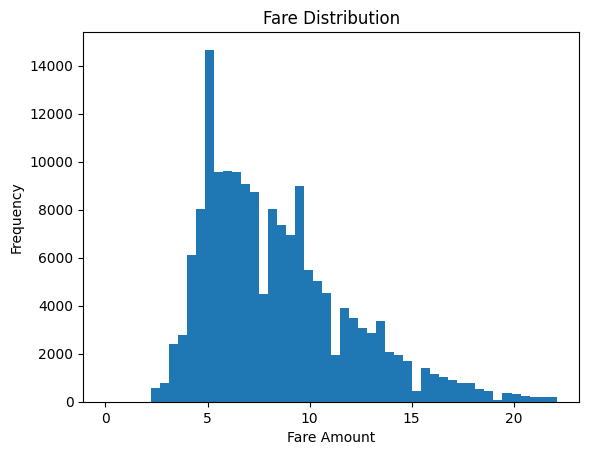

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()

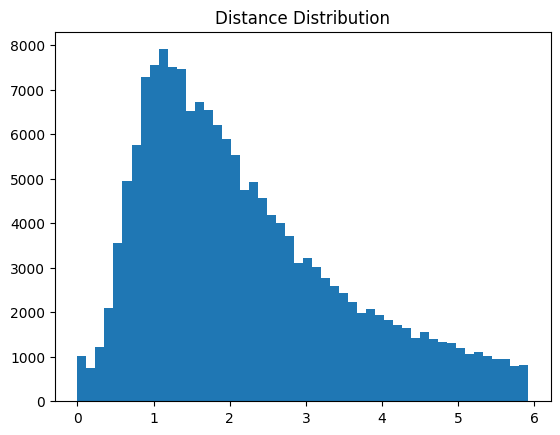

In [6]:
plt.hist(df['distance_km'], bins=50)
plt.title("Distance Distribution")
plt.show()

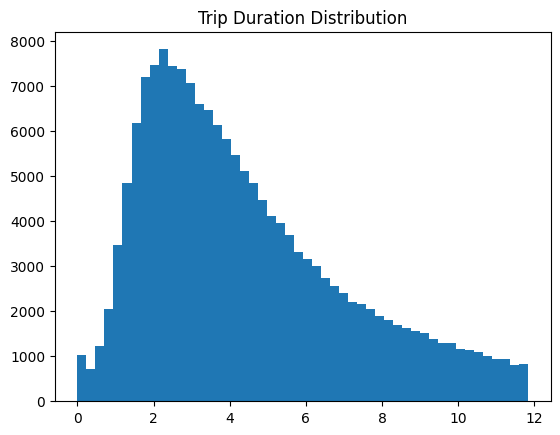

In [7]:
plt.hist(df['duration_min'], bins=50)
plt.title("Trip Duration Distribution")
plt.show()

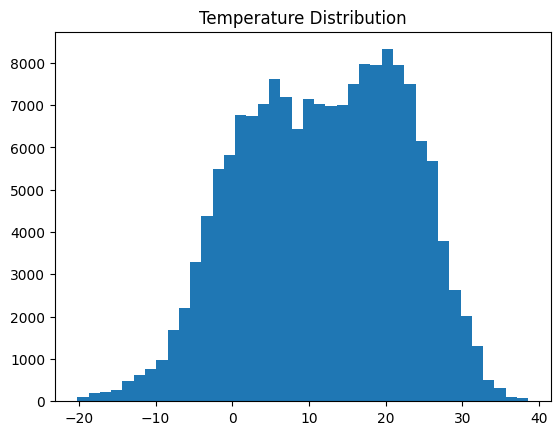

In [8]:
plt.hist(df['temperature'], bins=40)
plt.title("Temperature Distribution")
plt.show()

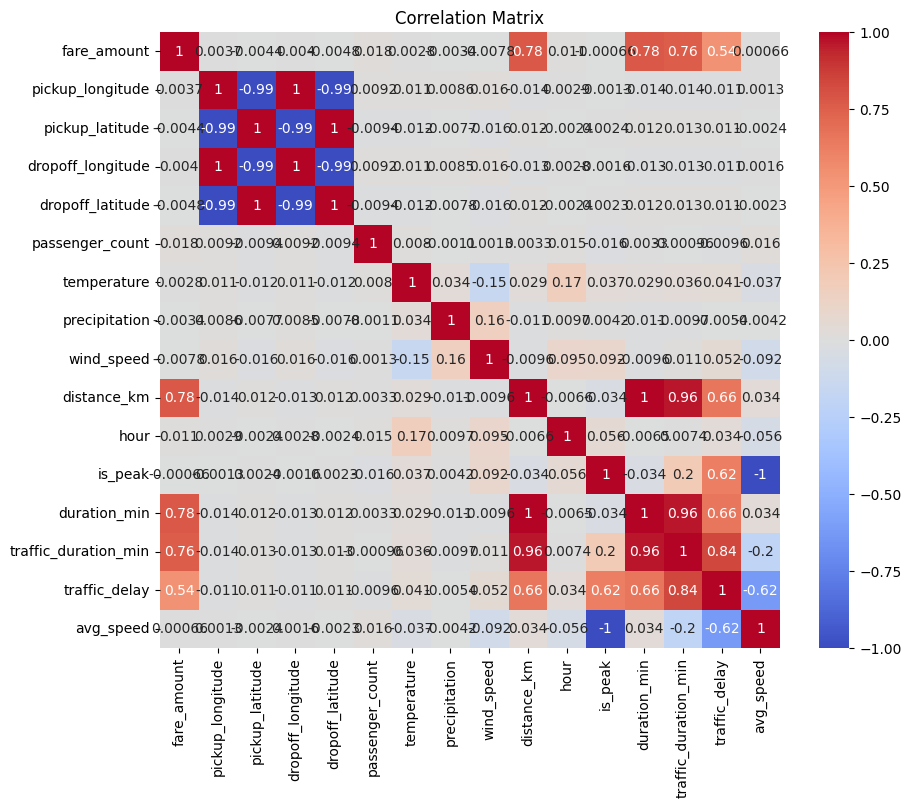

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

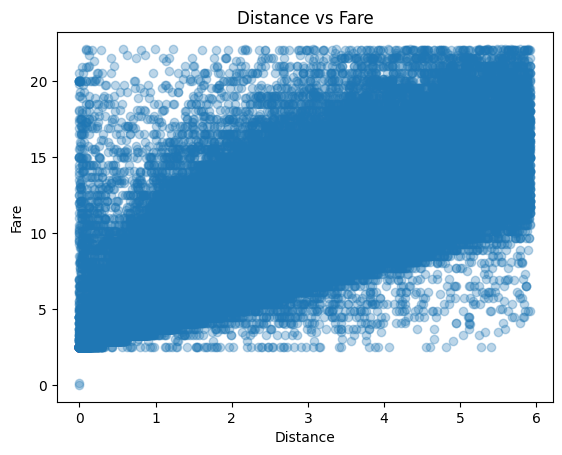

In [10]:
plt.scatter(df['distance_km'], df['fare_amount'], alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare")
plt.show()

In [11]:
df['rain_flag'] = df['precipitation'] > 0

df.groupby('rain_flag')['duration_min'].mean()

rain_flag
False    4.433142
True     4.315246
Name: duration_min, dtype: float64

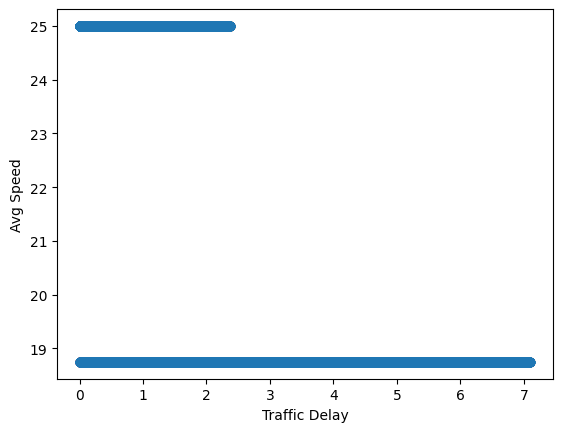

In [12]:
plt.scatter(df['traffic_delay'], df['avg_speed'], alpha=0.3)
plt.xlabel("Traffic Delay")
plt.ylabel("Avg Speed")
plt.show()

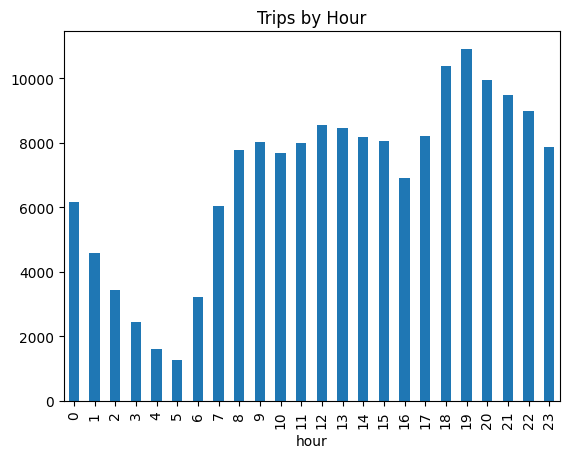

In [13]:
df.groupby('hour').size().plot(kind='bar')
plt.title("Trips by Hour")
plt.show()

In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

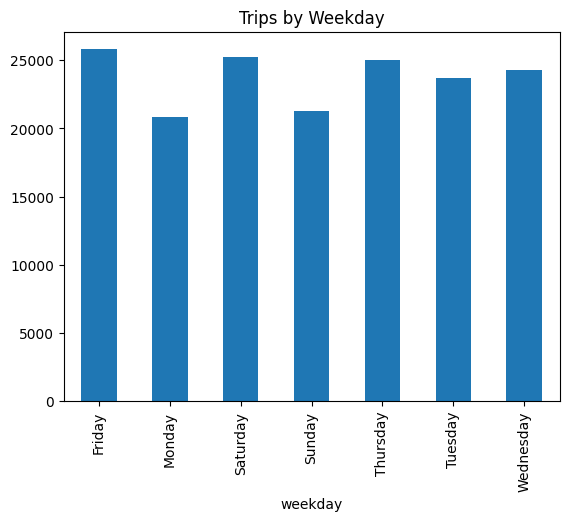

In [15]:
df['weekday'] = df['pickup_datetime'].dt.day_name()

df.groupby('weekday').size().plot(kind='bar')
plt.title("Trips by Weekday")
plt.show()

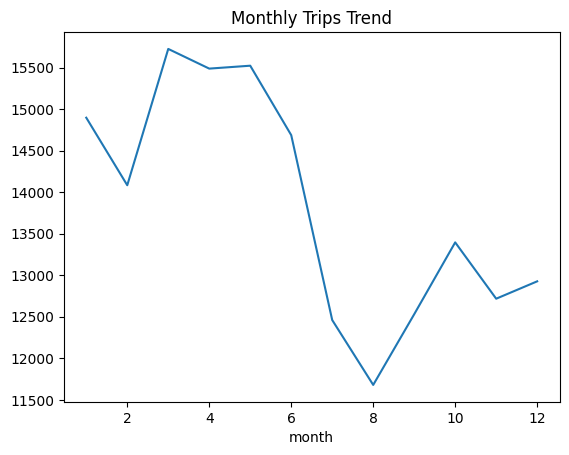

In [16]:
df['month'] = df['pickup_datetime'].dt.month

df.groupby('month').size().plot(kind='line')
plt.title("Monthly Trips Trend")
plt.show()

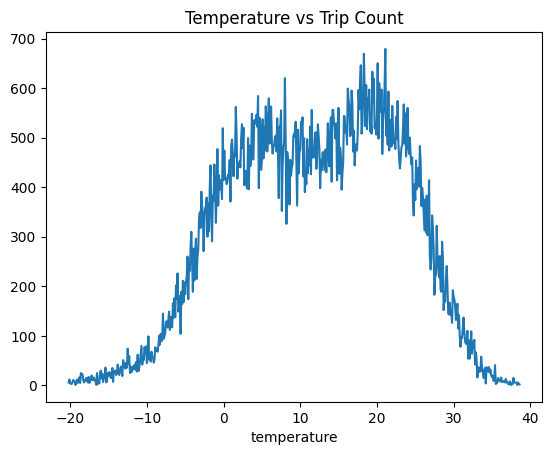

In [17]:
df.groupby('temperature').size().plot()
plt.title("Temperature vs Trip Count")
plt.show()

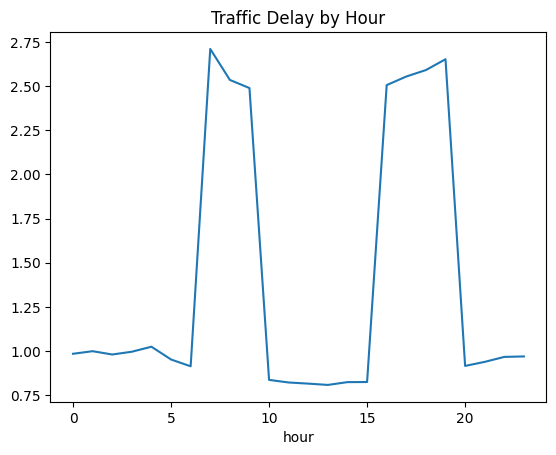

In [18]:
df.groupby('hour')['traffic_delay'].mean().plot(kind='line')
plt.title("Traffic Delay by Hour")
plt.show()

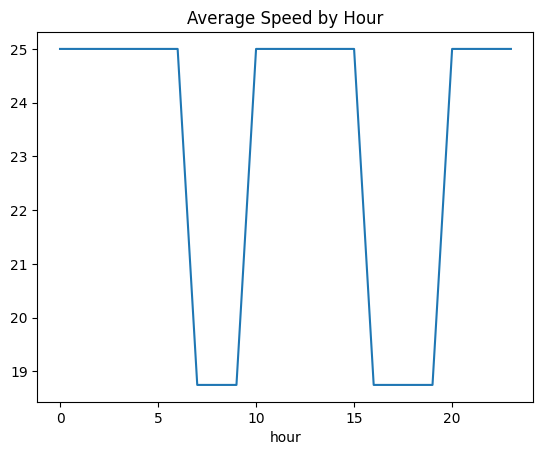

In [19]:
df.groupby('hour')['avg_speed'].mean().plot(kind='line')
plt.title("Average Speed by Hour")
plt.show()

In [20]:
df.groupby('is_peak')['fare_amount'].mean()

is_peak
False    8.410223
True     8.405301
Name: fare_amount, dtype: float64

In [21]:
df.groupby('rain_flag')['fare_amount'].mean()

rain_flag
False    8.413745
True     8.375158
Name: fare_amount, dtype: float64